In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import anndata as ad
from itertools import combinations
import networkx as nx
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import pickle
from scipy.spatial import ConvexHull, Delaunay
from scipy.stats import mannwhitneyu
import numpy as np
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from statsmodels.stats.multitest import multipletests
import squidpy as sq
import sys
import tifffile as tf
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed
sys.path.append("../src")
plt.rcParams['svg.fonttype'] = 'none'

In [84]:
from border_effects_kNN_del import sample_points_on_square, trunc_graphs, get_mibitof, get_squidpy_visium_datasets, delaunay_edges
from truncated_graphs import distance_to_border, compute_centrality_measures
from fit import fit_piece_wise_linear, fit_log, plot_piece_wise_linear, plot_log, fit_constant, fit_exponential_saturation, fit_piece_wise_linear_old
from evaluate_fit import log_likelihood, relative_likelihood, akaike_information_criterion, mse, support, relative_slope

In [4]:
np.random.seed(41)

In [5]:
with open("/data/bionets/je30bery/truncated_graphs/mibitof_coords/coords.pickle", "rb") as f:
    datasets = pickle.load(f)

In [6]:
lens = list()
for dataset in tqdm(datasets):
    coords = datasets[dataset]
    lens.append(len(coords))

100%|███████████████████████████████████████████████████████████████████████████████████| 1042/1042 [00:00<00:00, 941301.91it/s]


<Axes: ylabel='Count'>

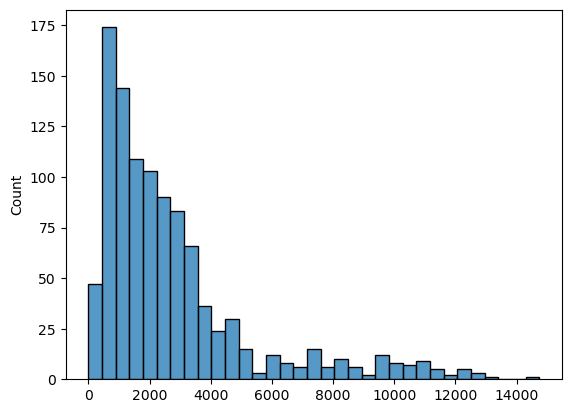

In [7]:
sns.histplot(lens)

In [8]:
def process_dataset_del(dataset):
    coords = datasets[dataset]
    distances = distance_to_border(coords)
    edges = delaunay_edges(coords)
    df = compute_centrality_measures(coords, edges)
    df["dataset"] = dataset
    return pd.concat([distances, df], axis=1)

In [9]:
def process_dataset_knn(dataset):
    coords = datasets[dataset]
    distances = distance_to_border(coords)
    edges = knn_edges(coords)
    df = compute_centrality_measures(coords, edges)
    df["dataset"] = dataset
    return pd.concat([distances, df], axis=1)

In [10]:
def process_dataset_rnn(dataset):
    coords = datasets[dataset]
    distances = distance_to_border(coords)
    edges = rnn_edges(coords)
    df = compute_centrality_measures(coords, edges)
    df["dataset"] = dataset
    return pd.concat([distances, df], axis=1)

In [12]:
try:
    delaunay_dfs = pd.read_csv("../results/delaunay_centralities.csv")    
except:
    dfs = []
    with ProcessPoolExecutor() as executor:
        futures = [executor.submit(process_dataset_del, dataset) for dataset in datasets]
    
        for future in tqdm(as_completed(futures), total=len(futures)):
            dfs.append(future.result())
    
    delaunay_dfs = pd.concat(dfs)
    delaunay_dfs.to_csv("../results/delaunay_centralities.csv")    

100%|███████████████████████████████████████████████████████████████████████████████████████| 1042/1042 [49:03<00:00,  2.82s/it]


In [ ]:
sns.scatterplot(delaunay_dfs.loc[0], x="distance_to_border", y="closeness")

In [63]:
measures = ["degree", "closeness", "betweenness", "harmonic", "clustering", "pagerank"]

def get_fits(dataset, dataset_df):
    d = dataset_df["distance_to_border"].values
    result_dfs = list()
    result = dict()
    for measure in measures:
        result[measure] = list()
        C_true = dataset_df[measure].values
        
        a, C_const = fit_constant(C_true)        
        ll = log_likelihood(C_true, C_const)
        result[measure] += [a, ll]
        
        m, c0, b, C_pieli = fit_piece_wise_linear(d, C_true)
        ll = log_likelihood(C_true, C_pieli)
        result[measure] += [m, c0, b, ll]
        
        a, b, C_log = fit_log(d, C_true)
        ll = log_likelihood(C_true, C_log)
        result[measure] += [a, b, ll]
        
        a, b, c, C_exp = fit_exponential_saturation(d, C_true)
        ll = log_likelihood(C_true, C_exp)
        result[measure] += [a, b, c, ll]
        result_dfs.append(pd.DataFrame(result[measure], columns=[measure], index=["const_a", "const_ll", "pieli_m", "pieli_c", "pieli_b", "pieli_ll", "log_a", "log_b", "log_ll", "exp_a", "exp_b", "exp_c", "exp_ll"]).T)
    result = pd.concat(result_dfs)
    result["dataset"] = dataset
    return result

In [127]:
for dataset, dataset_df in delaunay_dfs.groupby("dataset"):
    result = get_fits(dataset, dataset_df)
    break

array([[1030, 1076],
       [ 101,   33],
       [ 151,   34],
       ...,
       [1035, 2014],
       [1400, 2015],
       [1417, 2014]], dtype=int16)

In [129]:
measure = "closeness"
d = dataset_df["distance_to_border"].values

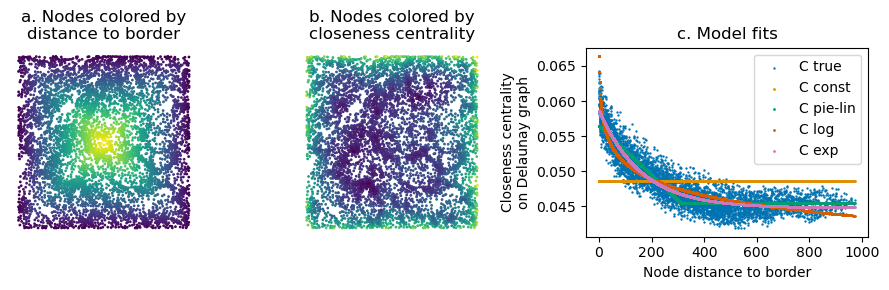

In [158]:
f, axs = plt.subplots(1, 3, figsize=(9,3), width_ratios=(2, 2, 3))
C_true = dataset_df[measure].values
a, C_const = fit_constant(C_true)    
m, c0, b, C_pieli = fit_piece_wise_linear(d, C_true)
a, b, C_log = fit_log(d, C_true)
a, b, c, C_exp = fit_exponential_saturation(d, C_true)

axs[0].scatter(coords[:,0], coords[:,1], c=d, s=1)
axs[1].scatter(coords[:,0], coords[:,1], c=C_true, s=1)
axs[0].axis("off")
axs[1].axis("off")

palette = sns.color_palette("colorblind", 5)
axs[2].scatter(dataset_df["distance_to_border"], C_true, label="C true", s=0.5, color=palette[0])
axs[2].scatter(dataset_df["distance_to_border"], C_const, label="C const", s=1, color=palette[1])
axs[2].scatter(dataset_df["distance_to_border"], C_pieli, label="C pie-lin", s=1, color=palette[2])
axs[2].scatter(dataset_df["distance_to_border"], C_log, label="C log", s=1, color=palette[3])
axs[2].scatter(dataset_df["distance_to_border"], C_exp, label="C exp", s=1, color=palette[4])
axs[2].legend()
axs[2].set_ylabel("Closeness centrality\non Delaunay graph")
axs[2].set_xlabel("Node distance to border")

axs[0].set_title("a. Nodes colored by\ndistance to border")
axs[1].set_title("b. Nodes colored by\ncloseness centrality")
axs[2].set_title("c. Model fits")

plt.tight_layout()
plt.savefig("../result_plots/model_fit.pdf")

In [152]:
result.loc["closeness"][["const_ll", "pieli_ll", "log_ll", "exp_ll"]]

const_ll    21170.113452
pieli_ll     25933.81326
log_ll      25810.447287
exp_ll      26435.389618
Name: closeness, dtype: object

In [73]:
plot_piece_wise_linear

<function fit.plot_piece_wise_linear(d, C, m_opt, c0_opt, b_opt, measure, graph_type, path=None)>

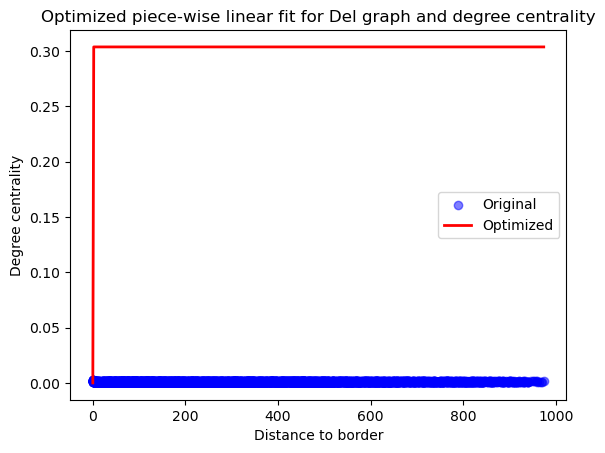

In [74]:
plot_piece_wise_linear(dataset_df["distance_to_border"], dataset_df["degree"], result.loc["degree"]["pieli_m"], result.loc["degree"]["pieli_c"], result.loc["degree"]["pieli_b"], "degree", "Del")

In [33]:

with ProcessPoolExecutor() as executor:
    futures = [executor.submit(get_fits, dataset) for dataset, dataset_df in delaunay_dfs.groupby("dataset")]

    for future in tqdm(as_completed(futures), total=len(futures)):
        dfs.append(future.result())

TypeError: unhashable type: 'slice'

In [27]:
m, c0, b, C_pieli = fit_piece_wise_linear(d,How  C_true)

Set parameter OptimalityTol to value 0.0001
Set parameter MIPGap to value 0.01
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (linux64 - "Ubuntu 24.04.4 LTS")

CPU model: AMD EPYC 7402 24-Core Processor, instruction set [SSE2|AVX|AVX2]
Thread count: 48 physical cores, 96 logical processors, using up to 32 threads

Non-default parameters:
MIPGap  0.01
OptimalityTol  0.0001
TSPort  1790

Optimize a model with 20852 rows, 10429 columns and 62538 nonzeros
Model fingerprint: 0xb68a323d
Model has 5213 quadratic objective terms
Model has 10426 quadratic constraints
Variable types: 5216 continuous, 5213 integer (5213 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+03]
  QMatrix range    [1e+00, 1e+00]
  QLMatrix range   [1e+00, 1e+03]
  Objective range  [0e+00, 0e+00]
  QObjective range [2e+00, 2e+00]
  Bounds range     [1e+00, 1e+03]
  RHS range        [1e+00, 1e+03]
  QRHS range       [4e-02, 6e-02]
Found heuristic solution: objective 52.1300000
Presolve added 10416 rows and 

In [29]:
a, b, C_log = fit_log(d, C_true)

In [30]:
a, b, c, C_exp = fit_exponential_saturation(d, C)

NameError: name 'fit_exponential_saturation' is not defined

In [ ]:
#plot_log(d, C, a, b, f, "closeness", path=None)

In [ ]:
log_likelihood(C_true=C_true, C_pred=C_pieli)

In [ ]:
log_likelihood(C_true=C_true, C_pred=C_log)

In [ ]:
relative_likelihood(C_true=C_true, C_model=C_pieli, C_baseline=C_log)